In [1]:
import numpy
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression #TODO: add yml
import cv2 #TODO: add yml
import os
import random
from tqdm import tqdm
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry, SamPredictor
from segment_anything.utils.transforms import ResizeLongestSide
import argparse
import time
from glob import glob
from utils import NpzDataset, NpzDataset_roi, transform_to_original, majority_voting, resize2origin, show_box
from torch.utils.data import DataLoader
import json
import pickle
import skimage
import SimpleITK as sitk
from metrics import compute_dice_coefficient


In [2]:
# SAM checkpoint
checkpoint = './checkpoints/SAM/sam_vit_b_01ec64.pth'
sam_model_type = 'vit_b'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# training_pool_path = 'datasets/RAINE_organ_51/MRI_LeftKidney/SAM_sampling/random_100_2024pool.json'
# with open(training_pool_path, 'r') as f:
#     training_pool = json.load(f)


In [5]:
axial_view = 'MRI_LeftKidney_axial'
sagittal_view = 'MRI_LeftKidney_sagittal'
coronal_view = 'MRI_LeftKidney_coronal'

training_axial = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', axial_view, 'train', '*.npz')))
training_sagittal = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', sagittal_view, 'train', '*.npz')))
training_coronal = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', coronal_view, 'train', '*.npz')))

training_3views = training_axial + training_sagittal + training_coronal
print(f'Number of training pool: {len(training_3views)}')

testing_axial = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', axial_view, 'test', '*.npz')))
testing_sagittal = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', sagittal_view, 'test', '*.npz')))
testing_coronal = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', coronal_view, 'test', '*.npz')))


Number of training pool: 120


In [5]:
import numpy as np

def majority_voting_optimized(arr1, arr2, arr3):
    """
    Perform majority voting on three 3D arrays.

    Parameters:
    - arr1, arr2, arr3: Three 3D numpy arrays of the same shape.

    Returns:
    - result: A 3D numpy array with the majority voted values.
    """

    if arr1.shape != arr2.shape or arr1.shape != arr3.shape:
        raise ValueError("Input arrays must have the same shape.")

    result_shape = arr1.shape
    result = np.empty(result_shape, dtype=arr1.dtype)

    for i in range(result_shape[0]):
        for j in range(result_shape[1]):
            for k in range(result_shape[2]):
                values = [arr1[i, j, k], arr2[i, j, k], arr3[i, j, k]]
                unique_values, counts = np.unique(values, return_counts=True)
                majority_value = unique_values[np.argmax(counts)]
                result[i, j, k] = majority_value

    return result

# Example usage:
# arr1 = np.random.randint(0, 2, size=(3, 3, 3))
# arr2 = np.random.randint(0, 2, size=(3, 3, 3))
# arr3 = np.random.randint(0, 2, size=(3, 3, 3))

# result = majority_voting(arr1, arr2, arr3)
# print("Input Arrays:")
# print(arr1)
# print(arr2)
# print(arr3)
# print("\nMajority Voted Result:")



In [6]:
import numpy as np
from scipy import stats

def majority_voting_mode(array1, array2, array3):
    # Stack the arrays along a new axis to create a 4D array
    stacked_arrays = np.stack((array1, array2, array3), axis=-1)

    # Use scipy.stats.mode to find the majority vote along the last axis
    result, _ = stats.mode(stacked_arrays, axis=-1)

    # The result is a 4D array with the last dimension of size 1, so we squeeze it to get a 3D array
    result = np.squeeze(result, axis=-1)

    return result.astype(np.uint8)

# Example usage:
# array1 = np.array([[1, 2], [3, 4]])
# array2 = np.array([[2, 2], [4, 4]])
# array3 = np.array([[1, 2], [3, 4]])

# result = majority_voting(array1, array2, array3)
# print(result)

In [4]:
def sam_infer_one_subject(npz_path, sam_model, device, box_seed):
    dataset = NpzDataset_roi([npz_path], box_seed)
    batch_size = len(dataset)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
    for embeddings, gts, bboxes in dataloader:
        with torch.no_grad():
            # convert box to 1024x1024 grid
            bbox_np = bboxes.numpy() # [0, 0, 256, 256]
            sam_trans = ResizeLongestSide(sam_model.image_encoder.img_size)
            box = sam_trans.apply_boxes(bbox_np, (gts.shape[-2], gts.shape[-1]))
            box_torch = torch.as_tensor(box, dtype=torch.float, device=device)
            if len(box_torch.shape) == 2:
                box_torch = box_torch[:, None, :] # (B, 1, 4)
            
            sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
                points=None,
                boxes=box_torch,
                masks=None,
            )
            pred_prob, _ = sam_model.mask_decoder(
                image_embeddings=embeddings.to(device), # (B, 256, 64, 64)
                image_pe=sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
                sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
                dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
                multimask_output=False,
                )
            pred_prob = torch.sigmoid(pred_prob)
            # convert soft mask to hard mask
            pred_prob = pred_prob.cpu().numpy().squeeze()
            pred_prob = np.stack(pred_prob, axis=0)
            preds = (pred_prob > 0.5).astype(np.uint8)

    gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
    return preds, gts

In [21]:
# calculate dice for training and testing set using roi bbox genarated by GT on SAM
mode = 'test'
box_seed = 2024
axial_view = 'MRI_LeftKidney_axial'
sagittal_view = 'MRI_LeftKidney_sagittal'
coronal_view = 'MRI_LeftKidney_coronal'

axial_set = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', axial_view, mode, '*.npz')))
agittal_set = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', sagittal_view, mode, '*.npz')))
coronal_set = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', coronal_view, mode, '*.npz')))

with open(f'datasets/RAINE_organ_51/MRI_LeftKidney/{mode}/sub_index.json', 'r') as f:
    sub_index = json.load(f)
id_set = sorted([k.split('.')[0] for k in sub_index.keys()])

sam_model = sam_model_registry[sam_model_type](checkpoint=checkpoint).to(device)
sam_model.eval()
dices_final = []
dices_axial = []
dices_sagittal = []
dices_coronal = []
for i in tqdm(range(len(id_set))):
    id = id_set[i]
    original_imgarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/{id}.FatImaging_W.nii.gz'))
    original_gtarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/labels/final/{id}.FatImaging_W.nii.gz'))
    original_gtarray = np.uint8(original_gtarray == 1)
    original_shape = original_gtarray.shape


    npz_path_axial = axial_set[i]
    preds_axial, gts_axial = sam_infer_one_subject(npz_path_axial, sam_model, device, box_seed)
    dice_axial = compute_dice_coefficient(gts_axial, preds_axial)
    dices_axial.append(dice_axial)

    npz_path_sagittal = agittal_set[i]
    preds_sagittal, gts_sagittal = sam_infer_one_subject(npz_path_sagittal, sam_model, device, box_seed)
    dice_sagittal = compute_dice_coefficient(gts_sagittal, preds_sagittal)
    dices_sagittal.append(dice_sagittal)

    npz_path_coronal = coronal_set[i]
    preds_coronal, gts_coronal = sam_infer_one_subject(npz_path_coronal, sam_model, device, box_seed)
    dice_coronal = compute_dice_coefficient(gts_coronal, preds_coronal)
    dices_coronal.append(dice_coronal)
    
    preds_axial_ori, preds_sagittal_ori, preds_coronal_ori = resize2origin(preds_axial, preds_sagittal, preds_coronal, original_shape, mode, id)
    preds_vote = majority_voting(preds_axial_ori, preds_sagittal_ori, preds_coronal_ori)
    dice = compute_dice_coefficient(original_gtarray, preds_vote)
    dices_final.append(dice)
  
np.save(os.path.join('results/dice/original', f'sam_vit_b_roi_{mode}ing_3views_seed{box_seed}.npy'), dices_final)
np.save(os.path.join('results/dice/original', f'sam_vit_b_roi_{mode}ing_axial_seed{box_seed}.npy'), dices_axial)
np.save(os.path.join('results/dice/original', f'sam_vit_b_roi_{mode}ing_sagittal_seed{box_seed}.npy'), dices_sagittal)
np.save(os.path.join('results/dice/original', f'sam_vit_b_roi_{mode}ing_coronal_seed{box_seed}.npy'), dices_coronal)

100%|██████████| 11/11 [04:04<00:00, 22.27s/it]


Text(0.5, 1.0, 'Dice coefficient for testing set using roi SAM on 3 view seed2024')

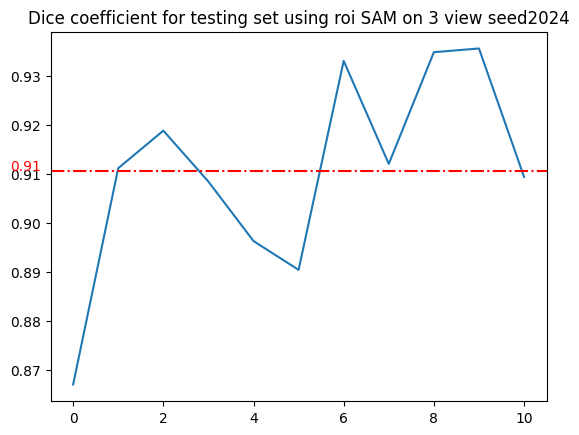

In [22]:
mean = np.mean(dices_final)
plt.plot(dices_final)
plt.axhline(y=mean, color='r', linestyle='-.')
# add mean value to the y axis
plt.text(-1.4, mean, f'{mean:.2f}', color='r')
plt.title(f'Dice coefficient for {mode}ing set using roi SAM on 3 view seed{box_seed}')

In [4]:
# get the image embedding and downsample the GT
train_embeddings = []
train_gts = []
print('Start dowwmsampling GT...')
t1 = time.time()
i = 0 
for fname in tqdm(training_coronal):
    # read data
    name = fname.split('/')[-1].split('.')[0]
    embeddings = np.load(fname)['img_embeddings']
    gts = np.load(fname)['gts']
    for emb, gt in zip(embeddings, gts):    # (256, 64, 64) (256, 256)
        emb = emb.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
        # print(emb.shape, gt.shape)
        train_embeddings.append(emb)

        gt = cv2.resize(gt, dsize=(64, 64), interpolation=cv2.INTER_NEAREST)
        train_gts.append(gt.flatten())

Start dowwmsampling GT...


100%|██████████| 40/40 [00:31<00:00,  1.27it/s]


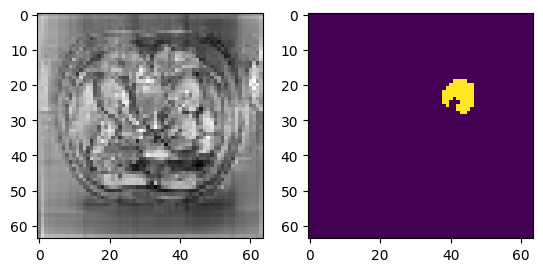

In [4]:
import matplotlib.pyplot as plt
test_downsampled_gt = cv2.resize(gts[22], dsize=(64, 64), interpolation=cv2.INTER_NEAREST)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(embeddings[22][128], cmap='gray')
ax[1].imshow(test_downsampled_gt)

In [8]:
train_embeddings = np.concatenate(train_embeddings)
train_gts = np.concatenate(train_gts)
print(train_embeddings.shape, train_gts.shape)

(6443008, 256) (6443008,)


In [9]:
# Create a linear regression model and fit it to the training data
model = LogisticRegression(max_iter=1000) 
model.fit(train_embeddings, train_gts)
task = 'MRI_LeftKidney_coronal_label'
pickle.dump(model, open(f'checkpoints/bbox_regression/{task}.pkl', 'wb'))

In [19]:
task = 'MRI_LeftKidney_3views_label'
model = pickle.load(open(f'checkpoints/bbox_regression/{task}.pkl', 'rb'))

# sagittal
fname_sagittal = training_sagittal[1]
imgs_sagittal = np.load(fname_sagittal)['imgs']
embeddings_sagittal = np.load(fname_sagittal)['img_embeddings']
gts_sagittal = np.load(fname_sagittal)['gts']
y_preds_sagittal = []
mask_preds_sagittal = []

for img_sagittal, emb_sagittal, gt_sagittal in zip(imgs_sagittal, embeddings_sagittal,  gts_sagittal):    # (256, 64, 64) (256, 256)

    emb_sagittal = emb_sagittal.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)e)
    y_pred_sagittal = model.predict(emb_sagittal)
    y_pred_sagittal = y_pred_sagittal.reshape((64,64))
    y_preds_sagittal.append(y_pred_sagittal)
    mask_pred_l_sagittal = cv2.resize(y_pred_sagittal, (gt_sagittal.shape[1], gt_sagittal.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_preds_sagittal.append(mask_pred_l_sagittal)
    
# coronal
fname_coronal = training_coronal[1]
imgs_coronal = np.load(fname_coronal)['imgs']
embeddings_coronal = np.load(fname_coronal)['img_embeddings']
gts_coronal = np.load(fname_coronal)['gts']
y_preds_coronal = []
mask_preds_coronal = []

for img_coronal, emb_coronal, gt_coronal in zip(imgs_coronal, embeddings_coronal, gts_coronal):    # (256, 64, 64) (256, 256)
    
    emb_coronal = emb_coronal.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
    y_pred_coronal = model.predict(emb_coronal)
    y_pred_coronal = y_pred_coronal.reshape((64,64))
    y_preds_coronal.append(y_pred_coronal)
    mask_pred_l_coronal = cv2.resize(y_pred_coronal, (gt_coronal.shape[1], gt_coronal.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_preds_coronal.append(mask_pred_l_coronal)
    
# axial
fname_axial = training_axial[1]
imgs_axial = np.load(fname_axial)['imgs']
embeddings_axial = np.load(fname_axial)['img_embeddings']
gts_axial = np.load(fname_axial)['gts']
y_preds_axial = []
mask_preds_axial = []
gts_downsampled = []

for img_axial, emb_axial, gt_axial in zip(imgs_axial, embeddings_axial, gts_axial):    # (256, 64, 64) (256, 256)

    emb_axial = emb_axial.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
    y_pred_axial = model.predict(emb_axial)
    y_pred_axial = y_pred_axial.reshape((64,64))
    y_preds_axial.append(y_pred_axial)
    mask_pred_l_axial = cv2.resize(y_pred_axial, (gt_axial.shape[1], gt_axial.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_preds_axial.append(mask_pred_l_axial)    

    gts_downsampled.append(cv2.resize(gt_axial, dsize=(64, 64), interpolation=cv2.INTER_NEAREST))


original_medsam = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/MedSAM/medsam_20230423_vit_b_0.0.1.pth'
sam_model = sam_model_registry['vit_b'](checkpoint=checkpoint).to(device)
sam_model.eval()
predictor = SamPredictor(sam_model)
mode = 'train'
id = training_axial[1].split('/')[-1].split('.')[0]
original_shape = (124, 234, 288)
print(id)
mask_preds_axial_ori, mask_preds_sagittal_ori, mask_preds_coronal_ori = resize2origin(mask_preds_axial, mask_preds_sagittal, mask_preds_coronal, original_shape, mode, id)
vote_mask_preds = majority_voting(mask_preds_axial_ori, mask_preds_sagittal_ori, mask_preds_coronal_ori)
view = 'MRI_LeftKidney_axial'
with open(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', view, mode, 'sub_index.json'), 'r') as f:
    sub_index = json.load(f)
    label_index = sub_index[f'{id}.FatImaging_W.nii.gz']
vote_mask_preds_roi = vote_mask_preds[label_index]
print(vote_mask_preds_roi.shape, imgs_axial.shape)
eroded_masks = []
dilate_masks = []
bboxes = []
preds = []

original_img = sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/{id}.FatImaging_W.nii.gz')
original_imgarray = sitk.GetArrayFromImage(original_img)
original_gtarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/labels/final/{id}.FatImaging_W.nii.gz'))
original_gtarray = np.uint8(original_gtarray==1)

for mask, img in zip(vote_mask_preds_roi, imgs_axial):
    
    mask = cv2.resize(mask, (256,256), interpolation=cv2.INTER_NEAREST)
    # Define the kernel for dilation
    kernel = np.ones((5,5), np.uint8)
    dilate_mask = mask

    for i in range(3):
        eroded_mask = cv2.erode(dilate_mask, kernel, iterations=1)
        dilate_mask = cv2.dilate(eroded_mask, kernel, iterations=1)
        
    
    dilate_masks.append(dilate_mask)
    eroded_masks.append(eroded_mask)
    # bbox 
    y_indices, x_indices = np.where(mask > 0)
    H, W = mask.shape
    if np.all(mask == 0):
        bbox = np.array([0, 0, H, W])
    else:
        # print(y_indices, x_indices, np.unique(gt))
        x_min, x_max = np.min(x_indices), np.max(x_indices)
        y_min, y_max = np.min(y_indices), np.max(y_indices)
        x_min = max(0, x_min - np.random.randint(0, 20))
        x_max = min(W, x_max + np.random.randint(0, 20))
        y_min = max(0, y_min - np.random.randint(0, 20))
        y_max = min(H, y_max + np.random.randint(0, 20))
        bbox = np.array([x_min, y_min, x_max, y_max])
    predictor.set_image(img)
    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=bbox[None, :],
        mask_input=None,
        multimask_output=False,
        )
    bboxes.append(bbox)
    preds.append(masks[0])

preds = np.array(preds)
bboxes = np.array(bboxes)
y_preds_axial = np.array(y_preds_axial)
mask_preds_axial = np.array(mask_preds_axial)

y_preds_sagittal = np.array(y_preds_sagittal)
mask_preds_sagittal = np.array(mask_preds_sagittal)

y_preds_coronal = np.array(y_preds_coronal)
mask_preds_coronal = np.array(mask_preds_coronal)

gts_downsampled = np.array(gts_downsampled)

eroded_masks = np.array(eroded_masks)
dilate_masks = np.array(dilate_masks)
# print(pred.shape, bboxes.shape, y_preds_axial.shape, mask_preds_axial.shape, gts_downsampled.shape, eroded_masks.shape, dilate_masks.shape)
compute_dice_coefficient(gts_axial, preds)

sub-10020
(40, 234, 288) (40, 256, 256, 3)


0.8210063046857262

Text(0.5, 1.0, 'GT on Coronal View')

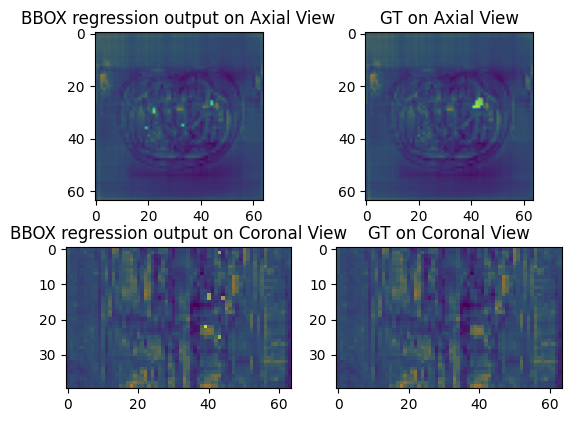

In [9]:
fig, ax = plt.subplots(2,2)
X = 2
ax[0,0].imshow(embeddings_axial[X][128])
ax[0,0].imshow(y_preds_axial[X], alpha=0.5)
ax[0,0].set_title('BBOX regression output on Axial View')

ax[0,1].imshow(embeddings_axial[X][128])
ax[0,1].imshow(gts_downsampled[X], alpha=0.5)
ax[0,1].set_title('GT on Axial View')

y = 32
ax[1,0].imshow(embeddings_axial[:,128,y,:])
ax[1,0].imshow(y_preds_axial[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
ax[1,0].set_title('BBOX regression output on Coronal View')

ax[1,1].imshow(embeddings_axial[:,128,y,:])
ax[1,1].imshow(gts_downsampled[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on Coronal View')


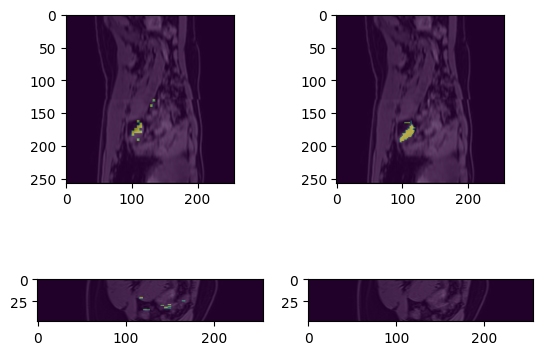

In [10]:
fig, ax = plt.subplots(2,2)
X = 2
mask_preds_sagittal = np.array(mask_preds_sagittal)
ax[0,0].imshow(imgs_sagittal[X])
ax[0,0].imshow(mask_preds_sagittal[X], alpha=0.5)
# ax[0,0].set_title('Upsampled output on Axial View')

ax[0,1].imshow(imgs_sagittal[X])
ax[0,1].imshow(gts_sagittal[X], alpha=0.5)
# ax[0,1].set_title('GT on Axial View')

y = 88
ax[1,0].imshow(imgs_sagittal[:,y,:])
ax[1,0].imshow(mask_preds_sagittal[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
# ax[1,0].set_title('Upsampled output on Coronal View')

ax[1,1].imshow(imgs_sagittal[:,y,:])
ax[1,1].imshow(gts_sagittal[:,y,:], alpha=0.5)
# ax[1,1].set_title('GT on Coronal View')

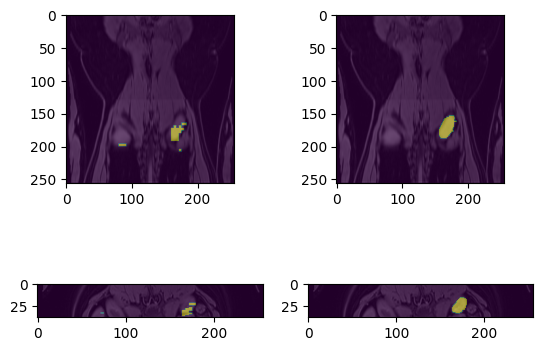

In [11]:
fig, ax = plt.subplots(2,2)
X = 2
mask_preds_coronal = np.array(mask_preds_coronal)
ax[0,0].imshow(imgs_coronal[X])
ax[0,0].imshow(mask_preds_coronal[X], alpha=0.5)
# ax[0,0].set_title('Upsampled output on Axial View')

ax[0,1].imshow(imgs_coronal[X])
ax[0,1].imshow(gts_coronal[X], alpha=0.5)
# ax[0,1].set_title('GT on Axial View')

y = 122
ax[1,0].imshow(imgs_coronal[:,y,:])
ax[1,0].imshow(mask_preds_coronal[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
# ax[1,0].set_title('Upsampled output on Coronal View')

ax[1,1].imshow(imgs_coronal[:,y,:])
ax[1,1].imshow(gts_coronal[:,y,:], alpha=0.5)
# ax[1,1].set_title('GT on Coronal View')

Text(0.5, 1.0, 'GT on Coronal View')

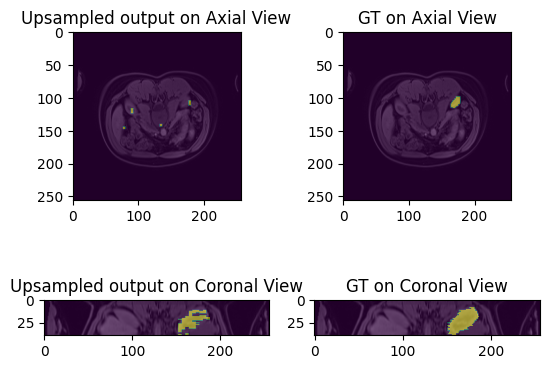

In [12]:
fig, ax = plt.subplots(2,2)
X = 2
mask_preds_axial = np.array(mask_preds_axial)
ax[0,0].imshow(imgs_axial[X])
ax[0,0].imshow(mask_preds_axial[X], alpha=0.5)
ax[0,0].set_title('Upsampled output on Axial View')

ax[0,1].imshow(imgs_axial[X])
ax[0,1].imshow(gts_axial[X], alpha=0.5)
ax[0,1].set_title('GT on Axial View')

y = 88
ax[1,0].imshow(imgs_axial[:,y,:])
ax[1,0].imshow(mask_preds_axial[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
ax[1,0].set_title('Upsampled output on Coronal View')

ax[1,1].imshow(imgs_axial[:,y,:])
ax[1,1].imshow(gts_axial[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on Coronal View')

sub-10020


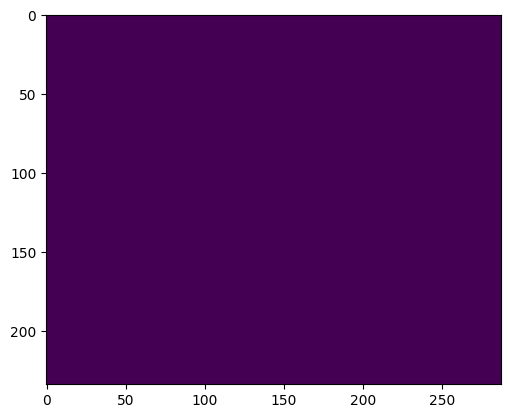

In [16]:
mode = 'train'
id = training_axial[1].split('/')[-1].split('.')[0]
original_shape = (124, 234, 288)
print(id)
mask_preds_axial_ori, mask_preds_sagittal_ori, mask_preds_coronal_ori = resize2origin(mask_preds_axial, mask_preds_sagittal, mask_preds_coronal, original_shape, mode, id)
vote_mask_preds = majority_voting(mask_preds_axial_ori, mask_preds_sagittal_ori, mask_preds_coronal_ori)


In [18]:
mask_preds_axial_ori.shape, mask_preds_sagittal_ori.shape, mask_preds_coronal_ori.shape, vote_mask_preds.shape

((124, 234, 288), (124, 234, 288), (124, 234, 288), (124, 234, 288))

Text(0.5, 1.0, 'GT on Coronal View')

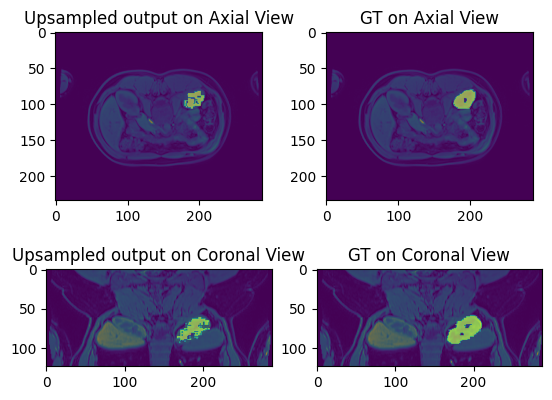

In [25]:
original_img = sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/{id}.FatImaging_W.nii.gz')
original_imgarray = sitk.GetArrayFromImage(original_img)
original_gtarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/labels/final/{id}.FatImaging_W.nii.gz'))
original_gtarray = np.uint8(original_gtarray==1)

fig, ax = plt.subplots(2,2)
X = 66
ax[0,0].imshow(original_imgarray[X])
ax[0,0].imshow(vote_mask_preds[X], alpha=0.5)
ax[0,0].set_title('Upsampled output on Axial View')

ax[0,1].imshow(original_imgarray[X])
ax[0,1].imshow(original_gtarray[X], alpha=0.5)
ax[0,1].set_title('GT on Axial View')

y = 88
ax[1,0].imshow(original_imgarray[:,y,:])
ax[1,0].imshow(vote_mask_preds[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
ax[1,0].set_title('Upsampled output on Coronal View')

ax[1,1].imshow(original_imgarray[:,y,:])
ax[1,1].imshow(original_gtarray[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on Coronal View')

In [26]:
compute_dice_coefficient(original_gtarray, vote_mask_preds)

0.6264673110310695

Text(0.5, 1.0, 'GT on Coronal View')

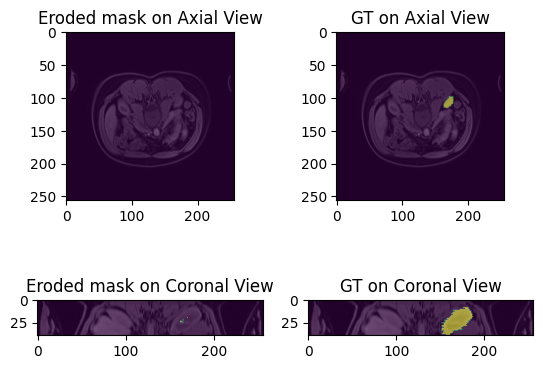

In [20]:
fig, ax = plt.subplots(2,2)
X = 2
ax[0,0].imshow(imgs_axial[X])
ax[0,0].imshow(eroded_masks[X], alpha=0.5)
ax[0,0].set_title('Eroded mask on Axial View')

ax[0,1].imshow(imgs_axial[X])
ax[0,1].imshow(gts_axial[X], alpha=0.5)
ax[0,1].set_title('GT on Axial View')

y = 88
ax[1,0].imshow(imgs_axial[:,y,:])
ax[1,0].imshow(eroded_masks[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
ax[1,0].set_title('Eroded mask on Coronal View')

ax[1,1].imshow(imgs_axial[:,y,:])
ax[1,1].imshow(gts_axial[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on Coronal View')

Text(0.5, 1.0, 'GT on Axial View')

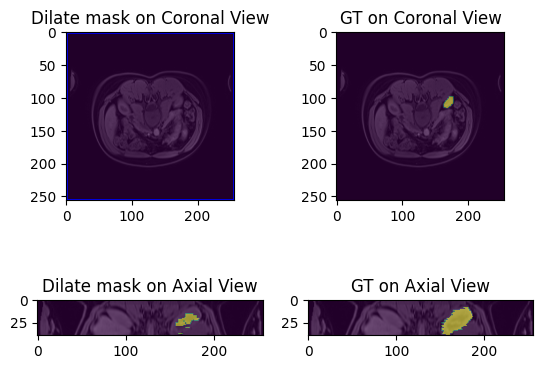

In [17]:
fig, ax = plt.subplots(2,2)
X = 2
ax[0,0].imshow(imgs_axial[X])
ax[0,0].imshow(dilate_masks[X], alpha=0.5)
show_box(bboxes[X], ax[0,0])
ax[0,0].set_title('Dilate mask on Coronal View')

ax[0,1].imshow(imgs_axial[X])
ax[0,1].imshow(gts_axial[X], alpha=0.5)
ax[0,1].set_title('GT on Coronal View')

y = 88
ax[1,0].imshow(imgs_axial[:,y,:])
ax[1,0].imshow(dilate_masks[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
ax[1,0].set_title('Dilate mask on Axial View')

ax[1,1].imshow(imgs_axial[:,y,:])
ax[1,1].imshow(gts_axial[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on Axial View')

Text(0.5, 1.0, 'GT on Axial View')

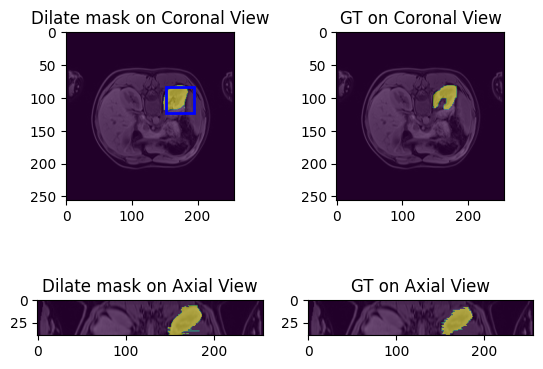

In [21]:
fig, ax = plt.subplots(2,2)
X = 22
ax[0,0].imshow(imgs_axial[X])
ax[0,0].imshow(preds[X], alpha=0.5)
show_box(bboxes[X], ax[0,0])
ax[0,0].set_title('Dilate mask on Coronal View')

ax[0,1].imshow(imgs_axial[X])
ax[0,1].imshow(gts_axial[X], alpha=0.5)
ax[0,1].set_title('GT on Coronal View')

y = 88
ax[1,0].imshow(imgs_axial[:,y,:])
ax[1,0].imshow(preds[:,y,:], alpha=0.5)
# show_box(bboxes[y], ax[0])
ax[1,0].set_title('Dilate mask on Axial View')

ax[1,1].imshow(imgs_axial[:,y,:])
ax[1,1].imshow(gts_axial[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on Axial View')

In [5]:
def bbox_infer(bbox_model, fname, sam_model, device):
    imgs = np.load(fname)['imgs']
    embeddings = np.load(fname)['img_embeddings']
    gts = np.load(fname)['gts']
    # print(f'shape of imgs: {imgs.shape}, shape of embeddings: {embeddings.shape}, shape of gts: {gts.shape}')
    bboxes = []
    pred = []
    for img, emb, gt in zip(imgs, embeddings, gts):    # (256, 64, 64) (256, 256)
        emb_transpose = emb.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
        y_pred = bbox_model.predict(emb_transpose)
        y_pred = y_pred.reshape((64,64))
        mask_pred_l = cv2.resize(y_pred, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Define the kernel for dilation
        kernel = np.ones((5, 5), np.uint8)
        dilate_mask = mask_pred_l
        for i in range(3):
            eroded_mask = cv2.erode(dilate_mask, kernel, iterations=1)
            dilate_mask = cv2.dilate(eroded_mask, kernel, iterations=1)
        # eroded_mask = cv2.erode(mask_pred_l, kernel, iterations=3)
        # dilate_mask = cv2.dilate(eroded_mask, kernel, iterations=5)

        # bbox 
        y_indices, x_indices = np.where(dilate_mask > 0)
        H, W = dilate_mask.shape
        if np.all(dilate_mask == 0):
                bbox = np.array([0, 0, H, W])
        else:
            # print(y_indices, x_indices, np.unique(gt))
            x_min, x_max = np.min(x_indices), np.max(x_indices)
            y_min, y_max = np.min(y_indices), np.max(y_indices)
            np.random.seed(2023)
            x_min = max(0, x_min - np.random.randint(0, 20))
            x_max = min(W, x_max + np.random.randint(0, 20))
            y_min = max(0, y_min - np.random.randint(0, 20))
            y_max = min(H, y_max + np.random.randint(0, 20))
            bbox = np.array([x_min, y_min, x_max, y_max])
        # predictor.set_image(img)
        # masks, _, _ = predictor.predict(
        #     point_coords=None,
        #     point_labels=None,
        #     box=bbox[None, :],
        #     multimask_output=False,
        #     )
        
        with torch.no_grad():
            sam_trans = ResizeLongestSide(sam_model.image_encoder.img_size)
            bbox_trans = sam_trans.apply_boxes(bbox, (H, W))
            box_torch = torch.as_tensor(bbox_trans, dtype=torch.float32, device=device)
            if len(box_torch.shape) == 2:
                box_torch = box_torch[:, None, :]  # (B, 1, 4)

            sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
                points=None,
                boxes=box_torch,
                masks=None,
            )

        medsam_seg_prob, _ = sam_model.mask_decoder(
            image_embeddings=torch.as_tensor(emb).to(device), # (B, 256, 64, 64)
            image_pe=sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
            multimask_output=False,
            )
        medsam_seg_prob = torch.sigmoid(medsam_seg_prob)
        # convert soft mask to hard mask
        medsam_seg_prob = medsam_seg_prob.cpu().detach().numpy().squeeze()
        medsam_seg_prob = np.stack(medsam_seg_prob, axis=0)
        medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)

        bboxes.append(bbox)
        pred.append(medsam_seg)
    pred = np.array(pred)
    bboxes = np.array(bboxes)
    return pred, bboxes, imgs, gts

In [14]:
def upsampled_vote(bbox_model, index, mode, original_shape):
    axial_view = 'MRI_LeftKidney_axial'
    sagittal_view = 'MRI_LeftKidney_sagittal'
    coronal_view = 'MRI_LeftKidney_coronal'

    axial_set = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', axial_view, mode, '*.npz')))
    sagittal_set = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', sagittal_view, mode, '*.npz')))
    coronal_set = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', coronal_view, mode, '*.npz')))

    # sagittal
    fname_sagittal = sagittal_set[index]
    id = os.path.basename(fname_sagittal).split('.')[0]
    imgs_sagittal = np.load(fname_sagittal)['imgs']
    embeddings_sagittal = np.load(fname_sagittal)['img_embeddings']
    gts_sagittal = np.load(fname_sagittal)['gts']
    y_preds_sagittal = []
    mask_preds_sagittal = []

    for img_sagittal, emb_sagittal, gt_sagittal in zip(imgs_sagittal, embeddings_sagittal,  gts_sagittal):    # (256, 64, 64) (256, 256)

        emb_sagittal = emb_sagittal.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)e)
        y_pred_sagittal = bbox_model.predict(emb_sagittal)
        y_pred_sagittal = y_pred_sagittal.reshape((64,64))
        y_preds_sagittal.append(y_pred_sagittal)
        mask_pred_l_sagittal = cv2.resize(y_pred_sagittal, (gt_sagittal.shape[1], gt_sagittal.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_preds_sagittal.append(mask_pred_l_sagittal)
        
    # coronal
    fname_coronal = coronal_set[index]
    imgs_coronal = np.load(fname_coronal)['imgs']
    embeddings_coronal = np.load(fname_coronal)['img_embeddings']
    gts_coronal = np.load(fname_coronal)['gts']
    y_preds_coronal = []
    mask_preds_coronal = []

    for img_coronal, emb_coronal, gt_coronal in zip(imgs_coronal, embeddings_coronal, gts_coronal):    # (256, 64, 64) (256, 256)
        
        emb_coronal = emb_coronal.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
        y_pred_coronal = bbox_model.predict(emb_coronal)
        y_pred_coronal = y_pred_coronal.reshape((64,64))
        y_preds_coronal.append(y_pred_coronal)
        mask_pred_l_coronal = cv2.resize(y_pred_coronal, (gt_coronal.shape[1], gt_coronal.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_preds_coronal.append(mask_pred_l_coronal)
        
    # axial
    fname_axial = axial_set[index]
    imgs_axial = np.load(fname_axial)['imgs']
    embeddings_axial = np.load(fname_axial)['img_embeddings']
    gts_axial = np.load(fname_axial)['gts']
    y_preds_axial = []
    mask_preds_axial = []
    # gts_downsampled = []
    for img_axial, emb_axial, gt_axial in zip(imgs_axial, embeddings_axial, gts_axial):    # (256, 64, 64) (256, 256)

        emb_axial = emb_axial.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
        y_pred_axial = bbox_model.predict(emb_axial)
        y_pred_axial = y_pred_axial.reshape((64,64))
        y_preds_axial.append(y_pred_axial)
        mask_pred_l_axial = cv2.resize(y_pred_axial, (gt_axial.shape[1], gt_axial.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_preds_axial.append(mask_pred_l_axial)    

        # gts_downsampled.append(cv2.resize(gt_axial, dsize=(64, 64), interpolation=cv2.INTER_NEAREST))

    mask_preds_axial_ori, mask_preds_sagittal_ori, mask_preds_coronal_ori = resize2origin(mask_preds_axial, mask_preds_sagittal, mask_preds_coronal, original_shape, mode, id)
    start_time = time.time()
    vote_mask_preds = majority_voting(mask_preds_axial_ori, mask_preds_sagittal_ori, mask_preds_coronal_ori)
    end_time = time.time()
    print(f'{id} Voting time: {end_time - start_time}')
    return vote_mask_preds

In [52]:
def bbox_vote_infer(vote_mask_preds, view, mode, index, sam_model, device):

    dataset = sorted(glob(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', view, mode, '*.npz')))
    id = dataset[index].split('/')[-1].split('.')[0]
    imgs = np.load(dataset[index])['imgs']
    embeddings = np.load(dataset[index])['img_embeddings']
    gts = np.load(dataset[index])['gts']
    
    with open(os.path.join('/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51', view, mode, 'sub_index.json'), 'r') as f:
        sub_index = json.load(f)
        label_index = sub_index[f'{id}.FatImaging_W.nii.gz']
    if 'axial' in view:
        vote_mask_preds_roi = vote_mask_preds[label_index]
    elif 'coronal' in view:
        vote_mask_preds_roi = vote_mask_preds[:,label_index,:]
    elif 'sagittal' in view:
        vote_mask_preds_roi = vote_mask_preds[:,:,label_index]
    bboxes = []
    preds = []
    for j, (img, emb, gt, _) in enumerate(zip(imgs, embeddings, gts, vote_mask_preds_roi)):    # (256, 64, 64) (256, 256)
        
        if 'axial' in view:
            mask_j = vote_mask_preds_roi[j]
        elif 'coronal' in view:
            mask_j = vote_mask_preds_roi[:,j,:]
        elif 'sagittal' in view:
            mask_j = vote_mask_preds_roi[:,:,j]
        # print(mask_j.shape, img.shape, emb.shape, gt.shape)
        # print(np.unique(mask_j))
        mask = cv2.resize(mask_j, (256,256), interpolation=cv2.INTER_NEAREST)
        # print(np.unique(mask))
        # bbox 
        y_indices, x_indices = np.where(mask > 0)
        H, W = mask.shape
        if np.all(mask == 0):
            bbox = np.array([0, 0, H, W])
            medsam_seg = np.zeros((H, W), dtype=np.uint8)

        else:
            # print(y_indices, x_indices, np.unique(gt))
            x_min, x_max = np.min(x_indices), np.max(x_indices)
            y_min, y_max = np.min(y_indices), np.max(y_indices)
            np.random.seed(2023)
            x_min = max(0, x_min - np.random.randint(0, 20))
            x_max = min(W, x_max + np.random.randint(0, 20))
            y_min = max(0, y_min - np.random.randint(0, 20))
            y_max = min(H, y_max + np.random.randint(0, 20))
            bbox = np.array([x_min, y_min, x_max, y_max])
        # predictor.set_image(img)
        # masks, _, _ = predictor.predict(
        #     point_coords=None,
        #     point_labels=None,
        #     box=bbox[None, :],
        #     multimask_output=False,
        #     )
        
            with torch.no_grad():
                sam_trans = ResizeLongestSide(sam_model.image_encoder.img_size)
                bbox_trans = sam_trans.apply_boxes(bbox, (H, W))
                box_torch = torch.as_tensor(bbox_trans, dtype=torch.float32, device=device)
                if len(box_torch.shape) == 2:
                    box_torch = box_torch[:, None, :]  # (B, 1, 4)
                if len(mask.shape) == 2:
                    mask = mask[None, :, :]
                    mask_torch = torch.as_tensor(mask, dtype=torch.float, device=device)
                    mask_torch = mask_torch[None, :, :, :]

                sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
                    points=None,
                    boxes=box_torch,
                    masks=None,
                )

            medsam_seg_prob, _ = sam_model.mask_decoder(
                image_embeddings=torch.as_tensor(emb).to(device), # (B, 256, 64, 64)
                image_pe=sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
                sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
                dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
                multimask_output=False,
                )
            medsam_seg_prob = torch.sigmoid(medsam_seg_prob)
            # convert soft mask to hard mask
            medsam_seg_prob = medsam_seg_prob.cpu().detach().numpy().squeeze()
            medsam_seg_prob = np.stack(medsam_seg_prob, axis=0)
            medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)

        bboxes.append(bbox)
        preds.append(medsam_seg)
    preds = np.array(preds)
    bboxes = np.array(bboxes)
    return preds, bboxes, imgs, gts

In [114]:
mode = 'train'
dices_coronal = []
# infer using 3 views
task = 'MRI_LeftKidney_3views_label'
bbox_model = pickle.load(open(f'checkpoints/bbox_regression/{task}.pkl', 'rb'))


original_medsam = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/MedSAM/medsam_15230423_vit_b_0.0.1.pth'
sam_model = sam_model_registry['vit_b'](checkpoint=checkpoint).to(device)
sam_model.eval()

for i,t in enumerate(tqdm(range(len(training_coronal)))):
    preds_coronal, vote_coronal, bboxes_coronal, eroded_masks_coronal, dilate_masks_coronal, imgs_coronal, gts_coronal = bbox_vote_infer(bbox_model, i, sam_model, device)
    # break
    dice_coronal = compute_dice_coefficient(gts_coronal, preds_coronal)
    dices_coronal.append(dice_coronal)

  0%|          | 0/40 [00:00<?, ?it/s]

sub-10010 Voting time: 18.70578646659851


  2%|▎         | 1/40 [00:22<14:46, 22.74s/it]

sub-10020 Voting time: 18.846317291259766


  5%|▌         | 2/40 [00:45<14:27, 22.84s/it]

...

 95%|█████████▌| 38/40 [14:27<00:45, 22.87s/it]

sub-51330 Voting time: 18.656443119049072


 98%|█████████▊| 39/40 [14:50<00:22, 22.77s/it]

sub-52220 Voting time: 18.87079882621765


100%|██████████| 40/40 [15:13<00:00, 22.85s/it]


In [115]:
np.save(os.path.join('./results/dice/bbox_regression', 'train_vote_upsampled_coronal_emb.npy'), dices_coronal)

Text(0.5, 1.0, 'Dice coefficient for training set using roi SAM on coronal view')

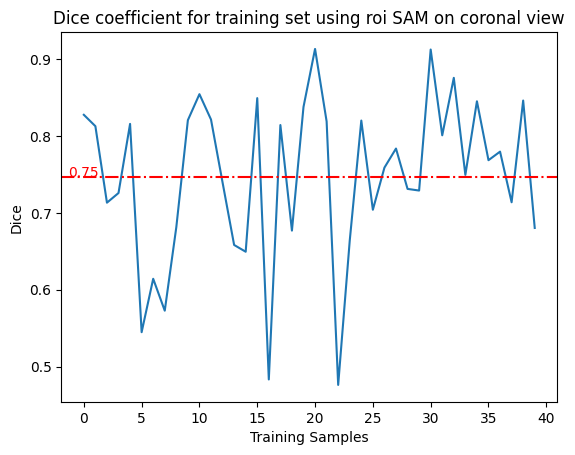

In [116]:
mean = np.mean(dices_coronal)
plt.plot(dices_coronal)
plt.axhline(y=mean, color='r', linestyle='-.')
# add mean value to the y axis
plt.text(-1.4, mean, f'{mean:.2f}', color='r')
plt.xlabel('Training Samples')
plt.ylabel('Dice')
plt.title('Dice coefficient for training set using roi SAM on coronal view')

In [58]:
mode = 'test'
task = 'MRI_LeftKidney_3views_label'
num_samples = 40
bbox_model = pickle.load(open(f'checkpoints/bbox_regression/{task}.pkl', 'rb'))

with open(f'datasets/RAINE_organ_51/MRI_LeftKidney/{mode}/sub_index.json', 'r') as f:
    sub_index = json.load(f)
id_set = sorted([k.split('.')[0] for k in sub_index.keys()])

sam_model = sam_model_registry['vit_b'](checkpoint=checkpoint).to(device)
sam_model.eval()
dices_final = []
for i in tqdm(range(len(id_set))):
    
    id = id_set[i]
    print(id)
    original_img = sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/{id}.FatImaging_W.nii.gz')
    original_imgarray = sitk.GetArrayFromImage(original_img)
    original_gtarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/labels/final/{id}.FatImaging_W.nii.gz'))
    original_gtarray = np.uint8(original_gtarray==1)
    original_shape = original_gtarray.shape

    if os.path.exists(os.path.join('datasets/vote_mask_preds/', f'{id}_3views_40samples.npy')):
        vote_mask_preds = np.load(os.path.join('datasets/vote_mask_preds/', f'{id}_3views_40samples.npy'))
    else:
        vote_mask_preds = upsampled_vote(bbox_model, i, mode, original_shape)
        np.save(os.path.join('datasets/vote_mask_preds/', f'{id}_3views_40samples.npy'), vote_mask_preds)

    preds_axial, bboxes_axial, imgs_axial, gts_axial = bbox_vote_infer(vote_mask_preds, 'MRI_LeftKidney_axial', mode, i, sam_model, device)

    preds_sagittal, bboxes_sagittal, imgs_sagittal, gts_sagittal = bbox_vote_infer(vote_mask_preds, 'MRI_LeftKidney_sagittal', mode, i, sam_model, device)
    preds_coronal, bboxes_coronal, imgs_coronal, gts_coronal = bbox_vote_infer(vote_mask_preds, 'MRI_LeftKidney_coronal', mode, i, sam_model, device)
    pred_axial_ori, pred_sagittal_ori, pred_coronal_ori = resize2origin(preds_axial, preds_sagittal, preds_coronal, original_shape, mode, id)
    pred_final = majority_voting(pred_axial_ori, pred_sagittal_ori, pred_coronal_ori)

    dice_final = compute_dice_coefficient(original_gtarray, pred_final)
    dices_final.append(dice_final)
    
np.save(os.path.join('./results/dice/bbox_regression', f'{mode}_vote_upsampled_3views_emb_sample{num_samples}.npy'), dices_final)

  0%|          | 0/40 [00:00<?, ?it/s]

sub-10010
(43, 234, 288) (43, 256, 256, 3) [0 1]
(124, 234, 47) (47, 256, 256, 3) [0 1]
(124, 36, 288) (36, 256, 256, 3) [0 1]


  2%|▎         | 1/40 [00:21<14:14, 21.91s/it]

sub-10020
(40, 234, 288) (40, 256, 256, 3) [0 1]
(124, 234, 48) (48, 256, 256, 3) [0 1]
(124, 38, 288) (38, 256, 256, 3) [0 1]


  5%|▌         | 2/40 [00:44<13:57, 22.03s/it]

...

 95%|█████████▌| 38/40 [13:58<00:44, 22.02s/it]

sub-51330
(43, 234, 288) (43, 256, 256, 3) [0 1]
(124, 234, 42) (42, 256, 256, 3) [0 1]
(124, 37, 288) (37, 256, 256, 3) [0 1]


 98%|█████████▊| 39/40 [14:20<00:21, 21.98s/it]

sub-52220
(35, 234, 288) (35, 256, 256, 3) [0 1]
(124, 234, 54) (54, 256, 256, 3) [0 1]
(124, 51, 288) (51, 256, 256, 3) [0 1]


100%|██████████| 40/40 [14:42<00:00, 22.06s/it]


Text(0.5, 1.0, 'Dice coefficient for training set using roi SAM on 3 views')

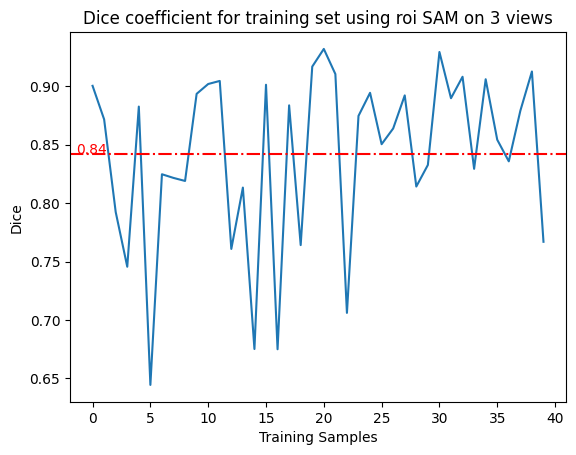

In [62]:
mean = np.mean(dices_final)
plt.plot(dices_final)
plt.axhline(y=mean, color='r', linestyle='-.')
# add mean value to the y axis
plt.text(-1.4, mean, f'{mean:.2f}', color='r')
plt.xlabel('Training Samples')
plt.ylabel('Dice')
plt.title('Dice coefficient for training set using roi SAM on 3 views')


In [12]:
original_gtarray.shape, pred_final.shape, original_imgarray.shape

((126, 234, 288), (124, 234, 288), (126, 234, 288))

Text(0.5, 0.98, 'sub-13170 axial emb prediction')

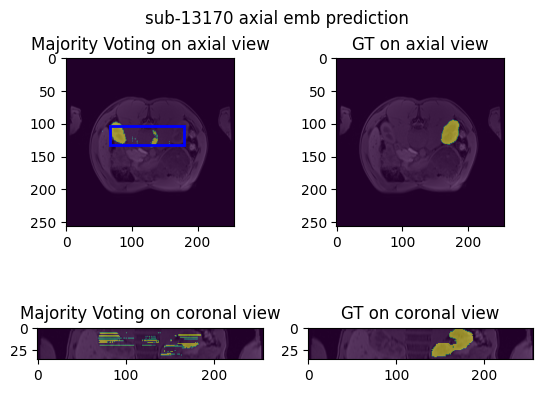

In [35]:
id = testing_axial[5].split('/')[-1].split('.')[0]
fig, ax = plt.subplots(2, 2)
x = 6
ax[0,0].imshow(imgs_axial[x,:,:], cmap='gray')
ax[0,0].imshow(preds[x,:,:], alpha=0.5)
show_box(bboxes[x], ax[0,0])
ax[0,0].set_title('Majority Voting on axial view')

ax[0,1].imshow(imgs_axial[x,:,:], cmap='gray')
ax[0,1].imshow(gts_axial[x,:,:], alpha=0.5)
ax[0,1].set_title('GT on axial view')

y = 120
ax[1,0].imshow(imgs_axial[:,y,:], cmap='gray')
ax[1,0].imshow(preds[:,y,:], alpha=0.5)
ax[1,0].set_title('Majority Voting on coronal view')

ax[1,1].imshow(imgs_axial[:,y,:], cmap='gray')
ax[1,1].imshow(gts_axial[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on coronal view')
plt.suptitle(f'{id} axial emb prediction')

In [16]:
dice = compute_dice_coefficient(gts_axial, preds)
print(gts_axial.shape, preds.shape, gts_axial.dtype, preds.dtype, dice)

(43, 256, 256) (43, 256, 256) uint8 uint8 0.35172530637600946


0.18053907441939313


Text(0.5, 1.0, 'GT on coronal view')

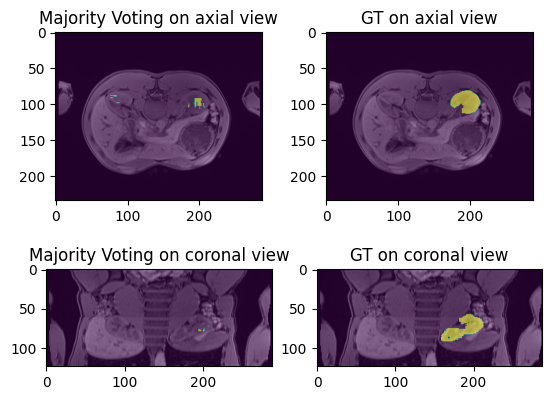

In [67]:
id = training_axial[5].split('/')[-1].split('.')[0]
original_img = sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/{id}.FatImaging_W.nii.gz')
original_imgarray = sitk.GetArrayFromImage(original_img)
original_gtarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/labels/final/{id}.FatImaging_W.nii.gz'))
original_gtarray = np.uint8(original_gtarray==1)
vote_dice = compute_dice_coefficient(original_gtarray, vote)
print(vote_dice)
fig, ax = plt.subplots(2, 2)
x = 75
ax[0,0].imshow(original_imgarray[x,:,:], cmap='gray')
ax[0,0].imshow(vote[x,:,:], alpha=0.5)
ax[0,0].set_title('Majority Voting on axial view')

ax[0,1].imshow(original_imgarray[x,:,:], cmap='gray')
ax[0,1].imshow(original_gtarray[x,:,:], alpha=0.5)
ax[0,1].set_title('GT on axial view')

y = 107
ax[1,0].imshow(original_imgarray[:,y,:], cmap='gray')
ax[1,0].imshow(vote[:,y,:], alpha=0.5)
ax[1,0].set_title('Majority Voting on coronal view')

ax[1,1].imshow(original_imgarray[:,y,:], cmap='gray')
ax[1,1].imshow(original_gtarray[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on coronal view')

In [69]:
mode = 'train'
id = training_axial[-1].split('/')[-1].split('.')[0]
orir_zeros = np.zeros((124, 234, 288), dtype=np.uint8)
original_shape = (124, 234, 288)
preds_resized = np.array([cv2.resize(p, (original_shape[2], original_shape[1]), interpolation=cv2.INTER_NEAREST) for p in preds], dtype=np.uint8)
preds_ori = transform_to_original(orir_zeros, mode, 'MRI_LeftKidney_axial', id, preds_resized)
vote_dice = compute_dice_coefficient(original_gtarray, preds_ori)

0.0012360135310954983


Text(0.5, 1.0, 'GT on coronal view')

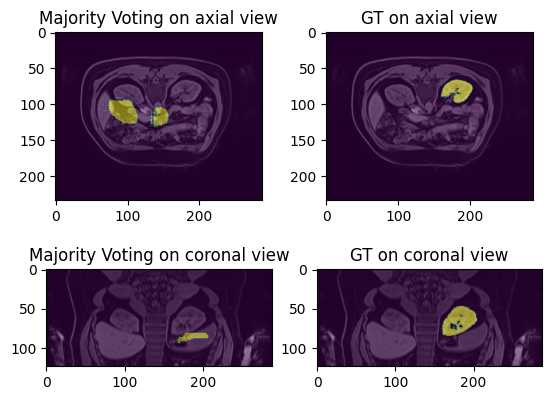

In [70]:
id = training_axial[0].split('/')[-1].split('.')[0]
original_img = sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/{id}.FatImaging_W.nii.gz')
original_imgarray = sitk.GetArrayFromImage(original_img)
original_gtarray = sitk.GetArrayFromImage(sitk.ReadImage(f'datasets/RAINE_organ_51/trainingset_51/labels/final/{id}.FatImaging_W.nii.gz'))
original_gtarray = np.uint8(original_gtarray==1)
vote_dice = compute_dice_coefficient(original_gtarray, vote)
print(vote_dice)
fig, ax = plt.subplots(2, 2)
x = 66
ax[0,0].imshow(original_imgarray[x,:,:], cmap='gray')
ax[0,0].imshow(preds_ori[x,:,:], alpha=0.5)
ax[0,0].set_title('Majority Voting on axial view')

ax[0,1].imshow(original_imgarray[x,:,:], cmap='gray')
ax[0,1].imshow(original_gtarray[x,:,:], alpha=0.5)
ax[0,1].set_title('GT on axial view')

y = 80
ax[1,0].imshow(original_imgarray[:,y,:], cmap='gray')
ax[1,0].imshow(preds_ori[:,y,:], alpha=0.5)
ax[1,0].set_title('Majority Voting on coronal view')

ax[1,1].imshow(original_imgarray[:,y,:], cmap='gray')
ax[1,1].imshow(original_gtarray[:,y,:], alpha=0.5)
ax[1,1].set_title('GT on coronal view')